lane intersections structure  
* key: vehicle num  
* val[i][0]: frame num  
* val[i][1]: vehicle 좌표  
* val[i][2:]: vehicle 좌표에서 수평선을 그었을 때 차선과의 교점  
모든 좌표는 lane net 결과 기준 (512, 256)

In [4]:
import json
import numpy as np
import os

with open('content/result.json', 'r') as file:
    lane_intersections = json.load(file)
print(lane_intersections)

def load_npy_files(directory):
    npy_files = [f for f in os.listdir(directory) if f.endswith('metric_depth.npy')]
    data_list = []
    for file in npy_files:
        data = np.load(os.path.join(directory, file))
        data_list.append(data)
    return data_list

directory_path = 'content/object_depths'
depth_map_list = load_npy_files(directory_path)

{'vehicle0': [[0, [118, 280], [118, 237.0], [118, 266.5], [118, 289.5]], [1, [118, 280], [118, 236.5], [118, 266.0], [118, 289.5]], [2, [119, 280], [119, 236.5], [119, 267.0], [119, 291.5]], [3, [119, 281], [119, 235.5], [119, 268.0], [119, 292.0]], [5, [119, 281], [119, 234.0], [119, 267.5], [119, 291.0]], [6, [119, 282], [119, 235.0], [119, 265.5], [119, 290.0]], [7, [119, 282], [119, 236.5], [119, 265.0], [119, 292.5]], [8, [119, 283], [119, 236.5], [119, 266.5], [119, 292.5]], [9, [119, 283], [119, 237.5], [119, 267.5], [119, 291.0]], [10, [119, 283], [119, 236.0], [119, 267.0], [119, 290.0]], [11, [119, 284], [119, 235.0], [119, 268.0], [119, 292.5]], [12, [119, 284], [119, 230.0], [119, 266.5], [119, 290.5]], [13, [119, 285], [119, 233.5], [119, 267.0], [119, 291.5]], [14, [119, 285], [119, 229.0], [119, 266.0], [119, 291.0]], [15, [119, 285], [119, 225.5], [119, 267.5], [119, 293.0]], [17, [119, 286], [119, 234.0], [119, 266.5], [119, 292.5]], [18, [119, 287], [119, 234.5], [119

In [5]:
# resizing 
lheight, lwidth =  256, 512 # lane net size
dheight, dwidth = depth_map_list[0].shape # depth map size

print(f"lanenet size: {lheight, lwidth}")
print(f"depth map size: {dheight, dwidth}")

resizing_val = dheight/lheight, dwidth/lwidth
print(f"resizing value: {resizing_val}")

lanenet size: (256, 512)
depth map size: (1080, 1920)
resizing value: (4.21875, 3.75)


In [6]:
for vehicle, values in lane_intersections.items():
    print(f"{vehicle}: {len(values)}")
    for value in values:
        for points in value[1:]:
            if points[0]>lheight or points[1]>lwidth:
                print(vehicle, points[0], points[1], lheight, lwidth)
                break
            points[0] *= resizing_val[0]
            points[1] *= resizing_val[1]
            if points[0]>dheight or points[1]>dwidth:
                print(vehicle, points[0], points[1], dheight, dwidth)
                break
            

vehicle0: 118
vehicle1: 77
vehicle8: 32
vehicle10: 7
vehicle13: 20
vehicle16: 8
vehicle19: 13
vehicle25: 3
vehicle27: 3
vehicle28: 2
vehicle29: 15
vehicle31: 13
vehicle36: 11


In [7]:
print(lane_intersections)

{'vehicle0': [[0, [497.8125, 1050.0], [497.8125, 888.75], [497.8125, 999.375], [497.8125, 1085.625]], [1, [497.8125, 1050.0], [497.8125, 886.875], [497.8125, 997.5], [497.8125, 1085.625]], [2, [502.03125, 1050.0], [502.03125, 886.875], [502.03125, 1001.25], [502.03125, 1093.125]], [3, [502.03125, 1053.75], [502.03125, 883.125], [502.03125, 1005.0], [502.03125, 1095.0]], [5, [502.03125, 1053.75], [502.03125, 877.5], [502.03125, 1003.125], [502.03125, 1091.25]], [6, [502.03125, 1057.5], [502.03125, 881.25], [502.03125, 995.625], [502.03125, 1087.5]], [7, [502.03125, 1057.5], [502.03125, 886.875], [502.03125, 993.75], [502.03125, 1096.875]], [8, [502.03125, 1061.25], [502.03125, 886.875], [502.03125, 999.375], [502.03125, 1096.875]], [9, [502.03125, 1061.25], [502.03125, 890.625], [502.03125, 1003.125], [502.03125, 1091.25]], [10, [502.03125, 1061.25], [502.03125, 885.0], [502.03125, 1001.25], [502.03125, 1087.5]], [11, [502.03125, 1065.0], [502.03125, 881.25], [502.03125, 1005.0], [502.0

In [17]:
fx, fy, cx, cy = 1316.81, 738.72, 960, 540
def get_3dpoint(frame_num, v, u):
    depth = depth_map_list[frame_num]
    d = depth[v,u]
    Z = d
    X = (v - cx) * Z / fx
    Y = (u - cy) * Z / fy
    return [X, Y, Z]

### 교점 확인  
이미지에 교점 직접 찍어봄

In [16]:
idx=0
print(lane_intersections.keys())
vehicle = 'vehicle0'

dict_keys(['vehicle0', 'vehicle1', 'vehicle8', 'vehicle10', 'vehicle13', 'vehicle16', 'vehicle19', 'vehicle25', 'vehicle27', 'vehicle28', 'vehicle29', 'vehicle31', 'vehicle36'])


10
502 1065
[np.float64(-14.554584115159553), np.float64(29.739720629885433), np.float64(41.84633604515994)]
502 881
[np.float64(-11.663196749005873), np.float64(15.479244553871663), np.float64(33.533218583096996)]
502 1005
[np.float64(-15.303977131031022), np.float64(27.697147362857095), np.float64(44.000939139547945)]
502 1096
[np.float64(-11.806166697501165), np.float64(25.548269179903), np.float64(33.944275914708534)]


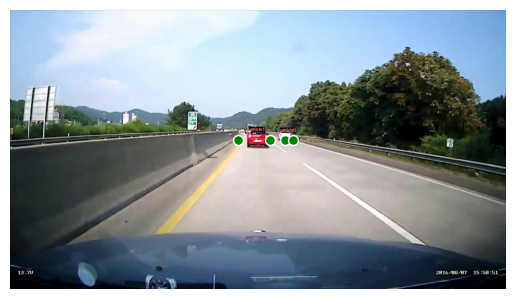

In [27]:
import random
import cv2
import matplotlib.pyplot as plt
#idx = random.randint(0, tracking_len-1)
#print(idx)

idx += 1
print(idx)

frame_num = lane_intersections[vehicle][idx][0]
img_path = f'content/tracker/{frame_num:06d}.png'
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

for point in lane_intersections[vehicle][idx][1:]:
    v, u = int(point[0]), int(point[1])
    plt.scatter([u], [v], color='green', s=50, edgecolor='white')
    print(v, u)
    print(get_3dpoint(frame_num, v, u))

plt.axis('off')
plt.show()

[[527.34375, 956.25], [527.34375, 956.25], [527.34375, 956.25], [527.34375, 956.25], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [527.34375, 960.0], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [527.34375, 956.25], [527.34375, 956.25], [527.34375, 956.25], [527.34375, 956.25], [527.34375, 956.25], [527.34375, 956.25], [523.125, 956.25], [523.125, 956.25], [523.125, 956.25], [518.90625, 952.5], [518.90625, 952.5], [518.90625, 952.5], [518.90625, 948.75], [518.90625, 948.75], [518.90625, 948.75], [518.90625, 948.75], [518.90625, 948.75], [518.90625, 945.0], [523.125, 945.0], [523.125, 945.0], [523.125, 945.0], [523.125, 945.0], [523.125, 945.0], [518.90625, 945.0], [523.1

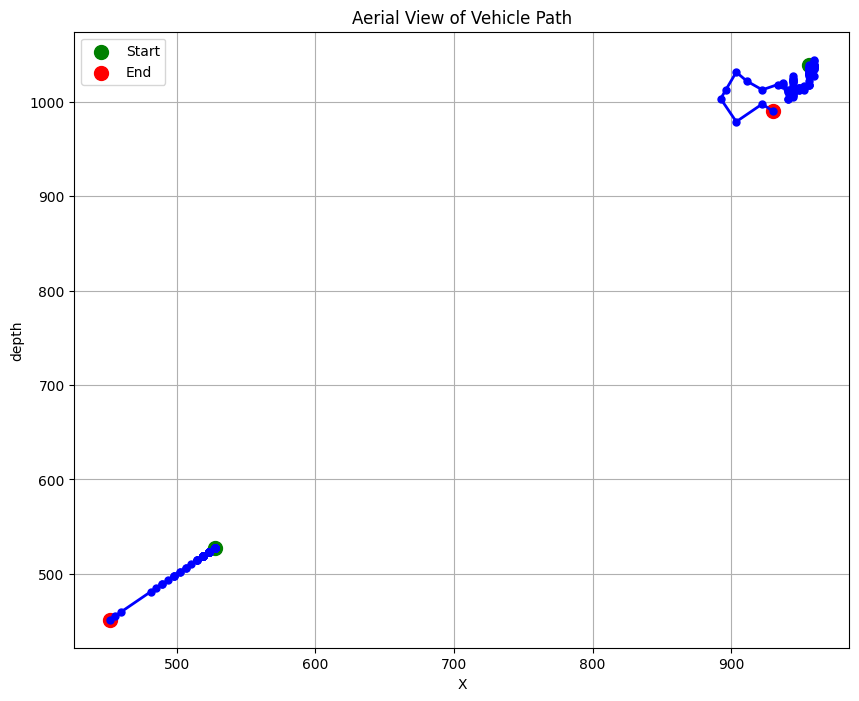

In [41]:
import matplotlib.pyplot as plt

vehicle = 'vehicle1'
points = lane_intersections[vehicle][:][1]

x = [point[1] for point in points]
y = [point[2] for point in points]
z = [point[3] for point in points]
print(x)
print(y)
print(z)

plt.figure(figsize=(10, 8))
plt.plot(x, z, marker='o', color='b', linestyle='-', linewidth=2, markersize=5)

plt.scatter(x[0], z[0], color='g', s=100, label='Start')
plt.scatter(x[-1], z[-1], color='r', s=100, label='End')

plt.xlabel('X')
plt.ylabel('depth')

plt.title('Aerial View of Vehicle Path')

plt.legend()

plt.grid(True)
plt.show()


/tmp/ipykernel_22632/1155097588.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


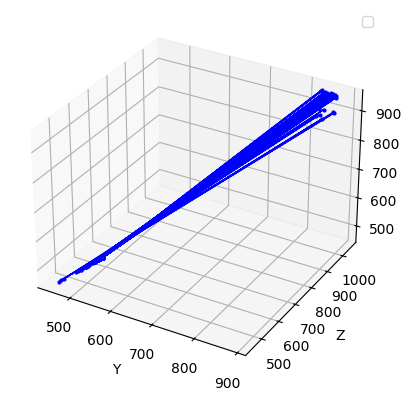

In [38]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

vehicle = 'vehicle1'
points = lane_intersections[vehicle]

x = [point[1] for point in points]
y = [point[2] for point in points]
z = [point[3] for point in points]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(y, z, x, marker='o', color='b', linestyle='-', linewidth=1, markersize=2)

ax.set_xlabel('Y')
ax.set_ylabel('Z')
ax.set_zlabel('X')

ax.legend()

plt.show()


In [10]:
fx, fy, cx, cy = 1316.81, 738.72, 960, 540
def get_3dpoint(frame_num, v, u):
    depth = depth_map_list[frame_num]
    d = depth[v,u]
    Z = d
    X = (v - cx) * Z / fx
    Y = (u - cy) * Z / fy
    return [X, Y, Z]

In [11]:
# vehicle당 모든 [frame_num, vehicle coor, lane coors] 계산
# depth map size: (1080, 1920)
realworld_values = {}
for vehicle, values in lane_intersections.items():
    points3d = []
    for value in values:
        frame_num = value[0]
        point3d = [frame_num]
        for points in value[1:]:
            point3d.append(get_3dpoint(frame_num, int(points[0]), int(points[1])))
        points3d.append(point3d)
    realworld_values[vehicle] = points3d

차선이 여러 개 있을 때, 차선 사이 폭이 모두 똑같다고 가정  
frame마다 value가 있고, 차선 사이 폭의 평균 계산 -> average_width    
계산된 frame당 평균 차선 폭의 평균을 구함  


In [ ]:
for point in realworld_values['vehicle0']:
    print(len(point))
    break

5


In [12]:
# lane width 계산
lane_widths_dict = {}

for vehicle, values in realworld_values.items():
    all_widths = []
    for frame_value in values:
        lane_num = len(frame_value)-2
        frame_widths = []
        # 차선의 좌표들로 차선 폭 계산
        for idx in range(lane_num-1):
            # print(idx, len(frame_value), vehicle, frame_value)
            frame_width = np.linalg.norm(np.array(frame_value[idx+2]) - np.array(frame_value[idx+3])) # frame num, vehicle coor 제외  
            frame_widths.append(frame_width)
        all_widths.append(np.mean(frame_widths))
    lane_widths_dict[vehicle] = np.mean(all_widths)

/home/souen/ugrp/soeun/2024_UGRP/.ugrp/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/souen/ugrp/soeun/2024_UGRP/.ugrp/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [13]:
lane_widths_dict

{'vehicle0': np.float64(12.024941723552118),
 'vehicle1': np.float64(9.999178797046579),
 'vehicle8': np.float64(27.566008781502376),
 'vehicle10': np.float64(nan),
 'vehicle13': np.float64(nan),
 'vehicle16': np.float64(22.609190319957545),
 'vehicle19': np.float64(nan),
 'vehicle25': np.float64(nan),
 'vehicle27': np.float64(14.48974610855488),
 'vehicle28': np.float64(nan),
 'vehicle29': np.float64(17.990432935089455),
 'vehicle31': np.float64(35.874495333019105),
 'vehicle36': np.float64(12.94750500280793)}

차량 위치 계산  
1. 차량이 차선 사이에 위치 : 차량 x좌표가 min도 아니고 max도 아님    
2. 차량이 가장자리에 위치 : 차량 x좌표가 min혹은 max  

In [14]:
lane_ratios = {}
for vehicle, values in lane_intersections.items():
    vehicle_lane_ratios = []
    for value in values:
        frame_num = value[0]
        # print(vehicle, frame_num)
        x = sorted(value[1:], key=lambda x: x[0])
        for vehicle_idx in range(len(x)):
            if value[1][0] == x[vehicle_idx][0]:
                break
        if vehicle_idx==0:
            # 차량이 왼쪽 끝에 위치
            lane1 = get_3dpoint(frame_num, int(x[vehicle_idx+1][0]), int(x[vehicle_idx+1][1]))
            vehicle_point = get_3dpoint(frame_num, int(value[1][0]), int(value[1][1]))

            lane_width = lane_widths_dict[vehicle]
            ratio2 = np.linalg.norm(np.array(vehicle_point) - np.array(lane1)) / lane_width
            ratio1 = 1-ratio2

            if ratio1 < 0 or ratio2 < 0:
                print(f"{vehicle} {frame_num}: ratio1={ratio1}, ratio2={ratio2}/ {lane_width}")


            # print(frame_num, vehicle_idx, ratio1, ratio2, ratio1+ratio2)
            vehicle_lane_ratios.append([frame_num, vehicle_idx, ratio1, ratio2])
        
        elif vehicle_idx==len(x)-1:
            # 차량이 오른쪽 끝에 위치
            lane1 = get_3dpoint(frame_num, int(x[vehicle_idx-1][0]), int(x[vehicle_idx-1][1]))
            vehicle_point = get_3dpoint(frame_num, int(value[1][0]), int(value[1][1]))

            lane_width = lane_widths_dict[vehicle]
            ratio1 = np.linalg.norm(np.array(vehicle_point) - np.array(lane1)) / lane_width
            ratio2 = 1-ratio1

            if ratio1 < 0 or ratio2 < 0:
                print(f"{vehicle} {frame_num}: ratio1={ratio1}, ratio2={ratio2}/ {lane_width}")
            

            # print(frame_num, vehicle_idx, ratio1, ratio2, ratio1+ratio2)
            vehicle_lane_ratios.append([frame_num, vehicle_idx, ratio1, ratio2])

        else:
        # if vehicle_idx!=0 and vehicle_idx!=len(x)-1:
            # 차량이 차선 사이에 위치
            # print(value)
            # print(x)
            # print(vehicle_idx)
            # lane_width = lane_widths_dict[vehicle]

            lane1 = get_3dpoint(frame_num, int(x[vehicle_idx-1][0]), int(x[vehicle_idx-1][1]))
            lane2 = get_3dpoint(frame_num, int(x[vehicle_idx+1][0]), int(x[vehicle_idx+1][1]))
            vehicle_point = get_3dpoint(frame_num, int(value[1][0]), int(value[1][1]))

            lane_width = np.linalg.norm(np.array(lane2) - np.array(lane1))
            ratio1 = np.linalg.norm(np.array(vehicle_point) - np.array(lane1)) / lane_width
            ratio2 = np.linalg.norm(np.array(lane2) - np.array(vehicle_point)) / lane_width
            
            ratio_sum = ratio1+ratio2
            ratio1 = ratio1/ratio_sum
            ratio2 = ratio2/ratio_sum
            if ratio1 < 0 or ratio2 < 0:
                print(f"{vehicle} {frame_num}: ratio1={ratio1}, ratio2={ratio2}/ {lane_width}")

            # print(frame_num, vehicle_idx, ratio1, ratio2, ratio1+ratio2)
            vehicle_lane_ratios.append([frame_num, vehicle_idx, ratio1, ratio2])
    lane_ratios[vehicle] = vehicle_lane_ratios
        

vehicle0 0: ratio1=-0.9421472923766072, ratio2=1.9421472923766072/ 12.024941723552118
vehicle0 1: ratio1=-1.0637476966869124, ratio2=2.0637476966869124/ 12.024941723552118
vehicle0 2: ratio1=-1.8404268658736096, ratio2=2.8404268658736096/ 12.024941723552118
vehicle0 6: ratio1=-0.32878479965691465, ratio2=1.3287847996569147/ 12.024941723552118
vehicle0 8: ratio1=-0.9543415569030689, ratio2=1.9543415569030689/ 12.024941723552118
vehicle0 9: ratio1=-0.13383329884831263, ratio2=1.1338332988483126/ 12.024941723552118
vehicle0 11: ratio1=-0.3936000944910254, ratio2=1.3936000944910254/ 12.024941723552118
vehicle0 12: ratio1=-0.29603349427435366, ratio2=1.2960334942743537/ 12.024941723552118
vehicle0 13: ratio1=-0.37671450986982324, ratio2=1.3767145098698232/ 12.024941723552118
vehicle0 14: ratio1=-0.5882765394147154, ratio2=1.5882765394147154/ 12.024941723552118
vehicle0 17: ratio1=-0.05154005378547888, ratio2=1.0515400537854789/ 12.024941723552118
vehicle0 18: ratio1=-0.6284030648650616, rat

IndexError: list index out of range

In [15]:
lane_ratios

{'vehicle0': [[0,
   0,
   np.float64(-0.9421472923766072),
   np.float64(1.9421472923766072)],
  [1, 0, np.float64(-1.0637476966869124), np.float64(2.0637476966869124)],
  [2, 0, np.float64(-1.8404268658736096), np.float64(2.8404268658736096)],
  [3, 0, np.float64(0.3195880537212451), np.float64(0.6804119462787549)],
  [5, 0, np.float64(0.08882672199776376), np.float64(0.9111732780022362)],
  [6, 0, np.float64(-0.32878479965691465), np.float64(1.3287847996569147)],
  [7, 0, np.float64(0.2280707701275324), np.float64(0.7719292298724676)],
  [8, 0, np.float64(-0.9543415569030689), np.float64(1.9543415569030689)],
  [9, 0, np.float64(-0.13383329884831263), np.float64(1.1338332988483126)],
  [10, 0, np.float64(0.3855704533007487), np.float64(0.6144295466992513)],
  [11, 0, np.float64(-0.3936000944910254), np.float64(1.3936000944910254)],
  [12, 0, np.float64(-0.29603349427435366), np.float64(1.2960334942743537)],
  [13, 0, np.float64(-0.37671450986982324), np.float64(1.3767145098698232)],

In [9]:
import json
file_path = 'content/lane_ratio.json'
with open(file_path, 'w', encoding='utf-8') as json_file:
            json.dump(lane_ratios, json_file, ensure_ascii=False, indent=4)

In [10]:
file_path = 'content/vehicle_depth.json'
with open(file_path, 'w', encoding='utf-8') as json_file:
            json.dump(realworld_values, json_file, ensure_ascii=False, indent=4)

[[80.         80.         80.         ... 80.         80.
  80.        ]
 [80.         80.         80.         ... 80.         80.
  80.        ]
 [80.         80.         80.         ... 80.         80.
  80.        ]
 ...
 [ 5.9914045   5.9914045   5.44815066 ...  6.42386468  7.15923995
   7.15923995]
 [ 5.61288934  5.61288934  5.15888612 ...  6.06581362  6.68922646
   6.68922646]
 [ 5.61288934  5.61288934  5.15888612 ...  6.06581362  6.68922646
   6.68922646]]
(1080, 1920)


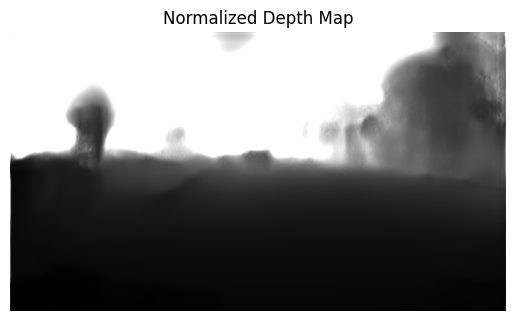

In [11]:
print(depth_map_list[0])
print(depth_map_list[0].shape)

import numpy as np
import cv2
import matplotlib.pyplot as plt

# depth_map_list[0] 가져오기
depth_map = depth_map_list[0]

# Min-Max Normalization (0 ~ 255)
depth_map_normalized = cv2.normalize(depth_map, None, 0, 255, cv2.NORM_MINMAX)

# uint8로 변환 (이미지로 변환하기 위해)
depth_map_uint8 = depth_map_normalized.astype(np.uint8)

# 이미지 시각화
plt.imshow(depth_map_uint8, cmap='gray')
plt.title('Normalized Depth Map')
plt.axis('off')
plt.show()


In [12]:
fx, fy, cx, cy = 194, 196, 960, 540
points3d_map_list = [[] for _ in range(len(depth_map_list))]
for i, depth in enumerate(depth_map_list):
    for v in range(dheight):
        for u in range(dwidth):
            d = depth[v, u]
            # if d == 0:
            #     continue
            Z = d
            X = (u - cx) * Z / fx
            Y = (v - cy) * Z / fy
            points3d_map_list[i].append((X, Y, Z))

    points3d_map_list[i] = np.array(points3d_map_list[i])

KeyboardInterrupt: 

In [ ]:
# import math
# vehicle당 모든 [frame_num, vehicle coor, lane coors] 계산
realworld_values = {}
for vehicle, values in lane_intersections.items():
    # points3d = [[frame_num, vehicle coor, lane coors], [frame_num, vehicle coor, lane coors], [frame_num, vehicle coor, lane coors]...]
    points3d = []
    for value in values:
        frame_num = value[0]
        # vehice과 차선의 real world 좌표 계산
        # point3d = [frame_num, vehicle coor, lane coors]
        point3d = [frame_num]
        # coor를 realworld 값으로 변환
        for points in value[1:]:
            # point_idx = math.floor(points[1]) * dheight + int(points[0])
            point3d.append(get_3dpoint(frame_num, int(points[0]), int(points[1])))
        points3d.append(point3d)
    realworld_values[vehicle] = points3d